In [42]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
import lightgbm as lgb
from sklearn.neural_network import MLPClassifier
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, precision_score,
                             recall_score, f1_score, classification_report, 
                             roc_auc_score, RocCurveDisplay, auc,silhouette_score,
                             adjusted_rand_score,precision_recall_curve,
                             average_precision_score,roc_curve)
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns


1. for the feature lists, right now we’re defining them in different places. maybe better to have all of them (core_features, sentinel_features, environmental_features, expanded_features, etc.) defined together in one spot near the top of the notebook. that way it’s cleaner and easier to swap combos later.

2. since the notebook is getting long, could you add a table of contents markdown cell right at the top? ideally one where you can click the links and it jumps straight to each section (e.g. Data Cleaning, Feature Engineering, Baseline Model (MLP neural network), XGBoost, etc.) so each model has its own section.

3. Separating by each audio moth (each audio moth has different acoustic features)

4. Graph the importance of each feature for each model

5. 

6. 

<!-- # Table of Contents
## <a id="Introduction"></a>1. Feature Selection
2. [Data Loading](#Data-Loading)
3. [Data Cleaning](#Data-Cleaning)
4. [Exploratory Data Analysis (EDA)](#EDA)
   - [Univariate Analysis](#Univariate)
   - [Bivariate Analysis](#Bivariate)
5. [Modeling](#Modeling)
6. [Conclusion](#Conclusion) -->
<!-- 
# Table of Contents
1. [Introduction](#introduction)
2. [Data Loading and Cleaning](#data-prep)
3. [Exploratory Data Analysis](#eda) -->

# Table of Contents
- [Data Loading](#data-loading)
- [Feature Engineering](#feature-engineering)
- [PCA Analysis](#pca-analysis)
- [KMeans Clustering](#kmeans-clustering)
- [HDBSCAN Clustering](#hdbscan-clustering)
- [Results & Discussion](#results-and-discussion)

In [12]:
# Load segments data
df = pd.read_csv("D:\Kashmir_World_Foundation\sliding_window_acoustic.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 769365 entries, 0 to 769364
Data columns (total 90 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   recorder_id             769365 non-null  object 
 1   original_clip_name      769365 non-null  object 
 2   segment_id              769365 non-null  int64  
 3   start_time              769365 non-null  float64
 4   end_time                769365 non-null  float64
 5   window_duration         769365 non-null  float64
 6   onset_confidence        769365 non-null  int64  
 7   has_onset               769365 non-null  bool   
 8   preliminary_rms         769365 non-null  float64
 9   RMS Energy              769365 non-null  float64
 10  Zero Crossing Rate      769365 non-null  float64
 11  Spectral Bandwidth      769365 non-null  float64
 12  Spectral Rolloff (85%)  769365 non-null  float64
 13  Spectral Flatness       769365 non-null  float64
 14  Spectral Contrast   

In [13]:
df.sample(10)

,recorder_id,original_clip_name,segment_id,start_time,end_time,window_duration,onset_confidence,has_onset,preliminary_rms,RMS Energy,...,Precipitation,Humidity,Weathercode,Weather Desc,Timestamp Local,Sunrise,Sunset,Time Of Day,Timestamp UTC,Datetime_hour
124825,Audio_Moth_1,Audio_Moth_1_20250318_132439.wav,1,0.36,0.96,0.6,4,True,0.012156,0.012156,...,0.4,71,51,Light drizzle,2025-03-18 13:00:00-06:00,2025-03-18 05:39:48.918172-06:00,2025-03-18 17:45:16.092609-06:00,afternoon,2025-03-18 19:00:00+00:00,13
650289,Audio_Moth_5,Audio_Moth_5_20250321_072730.wav,3,1.08,1.68,0.6,6,True,0.013400,0.013400,...,0.0,86,3,Overcast,2025-03-21 07:00:00-06:00,2025-03-21 05:38:12.435284-06:00,2025-03-21 17:45:06.084924-06:00,morning,2025-03-21 13:00:00+00:00,7
469802,Audio_Moth_2,Audio_Moth_2_20250318_004438.wav,4,1.44,2.04,0.6,8,True,0.103540,0.103540,...,0.0,89,0,Clear sky,2025-03-18 01:00:00-06:00,2025-03-18 05:39:48.918172-06:00,2025-03-18 17:45:16.092609-06:00,night,2025-03-18 07:00:00+00:00,1
511362,Audio_Moth_2,Audio_Moth_2_20250319_140431.wav,5,1.80,2.40,0.6,4,True,0.009954,0.009954,...,0.2,72,51,Light drizzle,2025-03-19 14:00:00-06:00,2025-03-19 05:39:16.886691-06:00,2025-03-19 17:45:12.872250-06:00,afternoon,2025-03-19 20:00:00+00:00,14
68716,Audio_Moth_1,Audio_Moth_1_20250317_210557.wav,4,1.44,2.04,0.6,6,True,0.184793,0.184793,...,0.0,97,3,Overcast,2025-03-17 21:00:00-06:00,2025-03-17 05:40:20.789893-06:00,2025-03-17 17:45:19.173328-06:00,night,2025-03-18 03:00:00+00:00,21
80312,Audio_Moth_1,Audio_Moth_1_20250319_160951.wav,1,0.36,0.96,0.6,10,True,0.015718,0.015718,...,0.0,76,0,Clear sky,2025-03-19 16:00:00-06:00,2025-03-19 05:39:16.886691-06:00,2025-03-19 17:45:12.872250-06:00,evening,2025-03-19 22:00:00+00:00,16
366631,Audio_Moth_4,Audio_Moth_4_20250320_230206.wav,6,2.16,2.76,0.6,9,True,0.073951,0.073951,...,0.0,86,0,Clear sky,2025-03-20 23:00:00-06:00,2025-03-20 05:38:44.718176-06:00,2025-03-20 17:45:09.530345-06:00,night,2025-03-21 05:00:00+00:00,23
244052,Audio_Moth_1,Audio_Moth_1_20250318_144836.wav,4,1.44,2.04,0.6,9,True,0.008154,0.008154,...,0.0,74,1,Mainly clear,2025-03-18 15:00:00-06:00,2025-03-18 05:39:48.918172-06:00,2025-03-18 17:45:16.092609-06:00,afternoon,2025-03-18 21:00:00+00:00,15
662101,Audio_Moth_6,Audio_Moth_6_20250320_090111.wav,6,2.16,2.76,0.6,8,True,0.028690,0.028690,...,0.0,69,2,Partly cloudy,2025-03-20 09:00:00-06:00,2025-03-20 05:38:44.718176-06:00,2025-03-20 17:45:09.530345-06:00,morning,2025-03-20 15:00:00+00:00,9
600343,Audio_Moth_5,Audio_Moth_5_20250319_035712.wav,2,0.72,1.32,0.6,11,True,0.177507,0.177507,...,0.0,96,0,Clear sky,2025-03-19 04:00:00-06:00,2025-03-19 05:39:16.886691-06:00,2025-03-19 17:45:12.872250-06:00,dawn,2025-03-19 10:00:00+00:00,4


In [14]:
df['Sim Type'].unique()

array([nan, 'Human Presence on Trail', 'Vehicle', 'Gunshot', 'Chainsaw',
       'Human Presence off Trail'], dtype=object)

# data-loading

<!-- <h2 id="data-prep">2. Data Loading and Cleaning</h2> -->

In [51]:
core_features = [
    'RMS Energy', 'Spectral Contrast', 'Spectral Flatness',
    'Spectral Bandwidth', 'Spectral Rolloff (85%)',
    'Onset Strength', 'MFCC_8', 'MFCC_9', 'MFCC_12', 'MFCC_13'
]

sentinel_features = ['is_Orange_billed_Sparrow', 'is_Antpitta', 'is_Pygmy_Tyrant']

expanded_features = core_features + [
    'is_Orange_billed_Sparrow', 'is_Antpitta', 'is_Pygmy_Tyrant',
    'Temperature', 'Humidity', 'Windspeed', 'Datetime_hour',
    'Human Activity Score', 'confidence'
]

combined_features = core_features + ['is_Orange_billed_Sparrow', 'is_Antpitta', 'is_Pygmy_Tyrant']

custom_features = [
    'is_Orange_billed_Sparrow', 'is_Antpitta', 'is_Pygmy_Tyrant',
    'Windspeed', 'Temperature', 'Datetime_hour', 
    'RMS Energy', 'Humidity', 'MFCC_12'
]

df['is_simulation'] = (~df['Sim Type'].isna()).astype(int)

def plot_feature_importance(model, feature_names, title):
    """
    Creates and displays a bar plot of feature importances.
    
    Args:
        model: A trained machine learning model with a .feature_importances_ attribute.
        feature_names (list or pd.Index): The names of the features.
        title (str): The title for the plot.
    """
    # Create a DataFrame with features and their importance scores
    importances = model.feature_importances_
    feature_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)
    
    # Create the bar plot
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')
    
    # Set plot titles and labels
    plt.title(title, fontsize=16)
    plt.xlabel('Importance Score', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.tight_layout()
    plt.show()

from sklearn.inspection import permutation_importance

def plot_permutation_importance(model, X_test, y_test, feature_names, title):
    """
    Calculates and displays a bar plot of permutation feature importances.
    
    Args:
        model: A trained scikit-learn model.
        X_test (pd.DataFrame or np.array): The test features.
        y_test (pd.Series or np.array): The test labels.
        feature_names (list or pd.Index): The names of the features.
        title (str): The title for the plot.
    """
    print("Calculating permutation importance...")
    
    # Calculate permutation importance
    # We use 'f1' as the scoring metric since that's what you're optimizing for
    result = permutation_importance(
        model, X_test, y_test, n_repeats=10, random_state=42, scoring='f1'
    )
    
    # Create a DataFrame with features and their importance scores
    importances = result.importances_mean
    feature_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)
    
    # Create the bar plot
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')
    
    # Set plot titles and labels
    plt.title(title, fontsize=16)
    plt.xlabel('Importance Score (Decrease in F1-Score)', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.tight_layout()
    plt.show()

print(f"Total samples: {len(df)}")
print(f"Simulation samples: {df['is_simulation'].sum()}")
print(f"Baseline samples: {(df['is_simulation'] == 0).sum()}")
print(f"Simulation types:\n{df['Sim Type'].value_counts()}")

Total samples: 769365
Simulation samples: 6657
Baseline samples: 762708
Simulation types:
Sim Type
Human Presence on Trail     5425
Vehicle                      812
Gunshot                      196
Chainsaw                     175
Human Presence off Trail      49
Name: count, dtype: int64


In [16]:
X = df[core_features].copy()
y = df['is_simulation'].copy()
print(f"Missing values in features: {X.isnull().sum().sum()}")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set - Simulation: {y_train.sum()}, Baseline: {(y_train == 0).sum()}")
print(f"Test set - Simulation: {y_test.sum()}, Baseline: {(y_test == 0).sum()}")


Missing values in features: 0
Train set - Simulation: 5326, Baseline: 610166
Test set - Simulation: 1331, Baseline: 152542


In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scale_pos_weight = (y_train == 0).sum() / y_train.sum()
print(f"Scale pos weight: {scale_pos_weight:.2f}")

Scale pos weight: 114.56


In [18]:
#Dataset A: Audio_Moth_1 only (open area)
df_moth1 = df[df['recorder_id'] == 'Audio_Moth_1'].copy()
print(f"Dataset A (Audio_Moth_1 - open area): {df_moth1.shape[0]} samples")

#Dataset B: All Audio_Moth recorders (including moth1)
df_all_moths = df[df['recorder_id'].str.contains('Audio_Moth', na=False)].copy()
print(f"Dataset B (All Audio_Moth recorders): {df_all_moths.shape[0]} samples")

print(f"\nTotal samples: {len(df)}")
print(f"Unique recorders: {df['recorder_id'].unique()}")
print(f"Audio_Moth recorders: {df_all_moths['recorder_id'].unique()}")

def prepare_features(df, dataset_name):
    print(f"\n=== {dataset_name} ===")
    
    df_clean = df[core_features].replace([np.inf, -np.inf], np.nan).dropna()
    keep_idx = df_clean.index
    df_subset = df.loc[keep_idx].copy()
    
    print(f"Shape after cleaning: {df_subset.shape}")
    print(f"Simulation samples: {df_subset['is_simulation'].sum()} ({df_subset['is_simulation'].mean():.2%})")
    
    return df_subset, df_clean.values

df_A, X_A = prepare_features(df_moth1, "Audio_Moth_1 (open area)")
df_B, X_B = prepare_features(df_all_moths, "All Audio_Moth recorders")

Dataset A (Audio_Moth_1 - open area): 332192 samples
Dataset B (All Audio_Moth recorders): 769365 samples

Total samples: 769365
Unique recorders: ['Audio_Moth_1' 'Audio_Moth_4' 'Audio_Moth_2' 'Audio_Moth_5'
 'Audio_Moth_6' 'Audio_Moth_3']
Audio_Moth recorders: ['Audio_Moth_1' 'Audio_Moth_4' 'Audio_Moth_2' 'Audio_Moth_5'
 'Audio_Moth_6' 'Audio_Moth_3']

=== Audio_Moth_1 (open area) ===
Shape after cleaning: (332192, 91)
Simulation samples: 1442 (0.43%)

=== All Audio_Moth recorders ===
Shape after cleaning: (769365, 91)
Simulation samples: 6657 (0.87%)


In [21]:
from sklearn.cluster import DBSCAN

def perform_pca_analysis(X, df_subset, dataset_name):
    """Perform PCA analysis and return transformed data"""
    print(f"\n=== PCA Analysis for {dataset_name} ===")
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    pca_full = PCA(random_state=42)
    pca_full.fit(X_scaled)
    
    print("Explained variance ratio by component:")
    for i, ratio in enumerate(pca_full.explained_variance_ratio_):
        print(f"Component {i+1}: {ratio:.2%} ({np.sum(pca_full.explained_variance_ratio_[:i+1]):.2%} cumulative)")
    
    n_components_90 = np.argmax(np.cumsum(pca_full.explained_variance_ratio_) >= 0.90) + 1
    print(f"Components needed for 90% variance: {n_components_90}")
    
    pca_cluster = PCA(n_components=min(5, len(core_features)), random_state=42)
    pca_viz = PCA(n_components=2, random_state=42)
    
    X_pca_cluster = pca_cluster.fit_transform(X_scaled)
    X_pca_viz = pca_viz.fit_transform(X_scaled)
    
    df_subset_copy = df_subset.copy()
    df_subset_copy['pca1'] = X_pca_viz[:, 0]
    df_subset_copy['pca2'] = X_pca_viz[:, 1]
    
    print(f"PCA clustering components explained variance: {pca_cluster.explained_variance_ratio_.sum():.2%}")
    print(f"PCA visualization components explained variance: {pca_viz.explained_variance_ratio_.sum():.2%}")
    
    return X_scaled, X_pca_cluster, X_pca_viz, df_subset_copy, scaler, pca_cluster, pca_viz

results_A = perform_pca_analysis(X_A, df_A, "Audio_Moth_1 (open area)")
X_A_scaled, X_A_pca_cluster, X_A_pca_viz, df_A_pca, scaler_A, pca_cluster_A, pca_viz_A = results_A

results_B = perform_pca_analysis(X_B, df_B, "All Audio_Moth recorders")
X_B_scaled, X_B_pca_cluster, X_B_pca_viz, df_B_pca, scaler_B, pca_cluster_B, pca_viz_B = results_B


=== PCA Analysis for Audio_Moth_1 (open area) ===
Explained variance ratio by component:
Component 1: 33.13% (33.13% cumulative)
Component 2: 22.98% (56.11% cumulative)
Component 3: 13.36% (69.48% cumulative)
Component 4: 10.72% (80.19% cumulative)
Component 5: 7.74% (87.94% cumulative)
Component 6: 4.27% (92.21% cumulative)
Component 7: 3.61% (95.82% cumulative)
Component 8: 2.15% (97.97% cumulative)
Component 9: 1.15% (99.12% cumulative)
Component 10: 0.88% (100.00% cumulative)
Components needed for 90% variance: 6
PCA clustering components explained variance: 87.94%
PCA visualization components explained variance: 56.11%

=== PCA Analysis for All Audio_Moth recorders ===
Explained variance ratio by component:
Component 1: 37.31% (37.31% cumulative)
Component 2: 21.70% (59.01% cumulative)
Component 3: 11.86% (70.87% cumulative)
Component 4: 10.22% (81.09% cumulative)
Component 5: 6.30% (87.38% cumulative)
Component 6: 4.89% (92.28% cumulative)
Component 7: 3.80% (96.07% cumulative)


In [22]:
print("=" * 60)
print("CONTAMINATION PARAMETER TUNING - Dataset A (with train/test split)")
print("=" * 60)

from sklearn.model_selection import train_test_split

X_A_train, X_A_test, y_sim_train, y_sim_test = train_test_split(
    X_A_scaled, df_A['is_simulation'], 
    test_size=0.3, random_state=42, stratify=df_A['is_simulation']
)

print(f"Train size: {len(X_A_train)}, Test size: {len(X_A_test)}")
print(f"Train sim rate: {y_sim_train.mean():.2%}, Test sim rate: {y_sim_test.mean():.2%}")

contamination_levels = [0.02, 0.03, 0.05, 0.08, 'auto']
results = []

for contamination in contamination_levels:
    print(f"\n--- Contamination = {contamination} ---")
    
    iso_forest = IsolationForest(
        contamination=contamination,
        random_state=42,
        n_estimators=100
    )
    
    iso_forest.fit(X_A_train)
    anomalies_test = iso_forest.predict(X_A_test)
    anomalies_binary_test = (anomalies_test == 1).astype(int)
    
    anomaly_rate = np.mean(anomalies_test == -1)
    print(f"Test anomaly detection rate: {anomaly_rate:.1%}")
    
    from sklearn.metrics import precision_score, recall_score, f1_score
    
    sim_precision = precision_score(y_sim_test, 1-anomalies_binary_test)
    sim_recall = recall_score(y_sim_test, 1-anomalies_binary_test)
    sim_f1 = f1_score(y_sim_test, 1-anomalies_binary_test)

    
    print(f"Simulation  - P: {sim_precision:.3f}, R: {sim_recall:.3f}, F1: {sim_f1:.3f}")

    results.append({
        'contamination': contamination,
        'anomaly_rate': anomaly_rate,
        'sim_precision': sim_precision,
        'sim_recall': sim_recall,
        'sim_f1': sim_f1
    })

results_df = pd.DataFrame(results)
print(f"\n" + "="*80)
print("SUMMARY TABLE:")
print("="*80)
print(results_df.round(3))

best_sim_f1 = results_df.loc[results_df['sim_f1'].idxmax()]

print(f"\nBest for Simulation F1: contamination = {best_sim_f1['contamination']} (F1 = {best_sim_f1['sim_f1']:.3f})")

CONTAMINATION PARAMETER TUNING - Dataset A (with train/test split)
Train size: 232534, Test size: 99658
Train sim rate: 0.43%, Test sim rate: 0.43%

--- Contamination = 0.02 ---
Test anomaly detection rate: 2.0%
Simulation  - P: 0.010, R: 0.046, F1: 0.016

--- Contamination = 0.03 ---
Test anomaly detection rate: 3.0%
Simulation  - P: 0.007, R: 0.051, F1: 0.013

--- Contamination = 0.05 ---
Test anomaly detection rate: 5.0%
Simulation  - P: 0.007, R: 0.083, F1: 0.013

--- Contamination = 0.08 ---
Test anomaly detection rate: 8.0%
Simulation  - P: 0.008, R: 0.148, F1: 0.015

--- Contamination = auto ---
Test anomaly detection rate: 14.3%
Simulation  - P: 0.011, R: 0.363, F1: 0.021

SUMMARY TABLE:
  contamination  anomaly_rate  sim_precision  sim_recall  sim_f1
0          0.02         0.020          0.010       0.046   0.016
1          0.03         0.030          0.007       0.051   0.013
2          0.05         0.050          0.007       0.083   0.013
3          0.08         0.080      

In [23]:
xgb_model = xgb.XGBClassifier(
    random_state=42,
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=20,
    eval_metric='logloss',
    reg_alpha=1,
    reg_lambda=1
)

xgb_model.fit(X_train_scaled, y_train)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

print(f"XGBoost ROC-AUC: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 0.9, 0.05)
best_f1 = 0
best_threshold = 0.5
results = []

for thresh in thresholds:
    y_pred_thresh = (y_pred_proba_xgb >= thresh).astype(int)
    precision = precision_score(y_test, y_pred_thresh)
    recall = recall_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)
    
    results.append([thresh, precision, recall, f1])
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thresh

results_df = pd.DataFrame(results, columns=['Threshold', 'Precision', 'Recall', 'F1'])
print(f"\nBest threshold: {best_threshold:.2f} with F1: {best_f1:.3f}")

print("\nTop 5 thresholds by F1 score:")
print(results_df.nlargest(5, 'F1')[['Threshold', 'Precision', 'Recall', 'F1']].round(3))

y_pred_xgb = (y_pred_proba_xgb >= best_threshold).astype(int)
print(f"\nFinal XGBoost Results (threshold={best_threshold:.2f}):")
print(classification_report(y_test, y_pred_xgb))

precision_recall_balance = results_df.copy()
precision_recall_balance['PR_diff'] = abs(precision_recall_balance['Precision'] - precision_recall_balance['Recall'])
best_balanced_idx = precision_recall_balance.loc[precision_recall_balance['F1'] > 0.08].nsmallest(1, 'PR_diff').index[0]
balanced_threshold = precision_recall_balance.loc[best_balanced_idx, 'Threshold']

y_pred_balanced = (y_pred_proba_xgb >= balanced_threshold).astype(int)
print(f"\nBalanced Precision-Recall Results (threshold={balanced_threshold:.2f}):")
print(classification_report(y_test, y_pred_balanced))

XGBoost ROC-AUC: 0.9436

Best threshold: 0.60 with F1: 0.271

Top 5 thresholds by F1 score:
    Threshold  Precision  Recall     F1
10       0.60      0.294   0.252  0.271
9        0.55      0.209   0.332  0.256
11       0.65      0.395   0.179  0.246
8        0.50      0.152   0.422  0.223
12       0.70      0.464   0.141  0.217

Final XGBoost Results (threshold=0.60):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    152542
           1       0.29      0.25      0.27      1331

    accuracy                           0.99    153873
   macro avg       0.64      0.62      0.63    153873
weighted avg       0.99      0.99      0.99    153873


Balanced Precision-Recall Results (threshold=0.60):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    152542
           1       0.29      0.25      0.27      1331

    accuracy                           0.99    153873
   macro avg       0.64      

In [ ]:
# LightGBM model
lgb_model = lgb.LGBMClassifier(
    random_state=42,
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    reg_alpha=1,
    reg_lambda=1,
    verbose=-1
)

lgb_model.fit(X_train_scaled, y_train)
y_pred_proba_lgb = lgb_model.predict_proba(X_test_scaled)[:, 1]

print(f"LightGBM ROC-AUC: {roc_auc_score(y_test, y_pred_proba_lgb):.4f}")

# Best threshold by F1
thresholds = np.arange(0.1, 0.8, 0.05)
best_f1_lgb = 0
best_thresh_lgb = 0.5

for thresh in thresholds:
    y_pred = (y_pred_proba_lgb >= thresh).astype(int)
    f1 = f1_score(y_test, y_pred)
    if f1 > best_f1_lgb:
        best_f1_lgb = f1
        best_thresh_lgb = thresh

y_pred_lgb = (y_pred_proba_lgb >= best_thresh_lgb).astype(int)
print(f"Best threshold: {best_thresh_lgb:.2f}, F1: {best_f1_lgb:.3f}")
print(classification_report(y_test, y_pred_lgb))

In [26]:
sentinel_species = [
    'Arremon aurantiirostris_Orange-billed Sparrow',
    'Hylopezus perspicillatus_Streak-chested Antpitta', 
    'Myiornis atricapillus_Black-capped Pygmy-Tyrant'
]

df['is_Orange_billed_Sparrow'] = (df['species'] == 'Arremon aurantiirostris_Orange-billed Sparrow')
df['is_Antpitta'] = (df['species'] == 'Hylopezus perspicillatus_Streak-chested Antpitta')
df['is_Pygmy_Tyrant'] = (df['species'] == 'Myiornis atricapillus_Black-capped Pygmy-Tyrant')

print("Sentinel species counts:")
for species in sentinel_species:
    count = (df['species'] == species).sum()
    print(f"{species}: {count}")

print(f"\nTotal species in dataset: {df['species'].nunique()}")
print("\nTop 10 most common species:")
print(df['species'].value_counts().head(10))

Sentinel species counts:
Arremon aurantiirostris_Orange-billed Sparrow: 13979
Hylopezus perspicillatus_Streak-chested Antpitta: 7567
Myiornis atricapillus_Black-capped Pygmy-Tyrant: 32097

Total species in dataset: 205

Top 10 most common species:
species
Ciccaba nigrolineata_Black-and-white Owl           174986
Pulsatrix perspicillata_Spectacled Owl             124740
Lophostrix cristata_Crested Owl                     70000
Myiothlypis fulvicauda_Buff-rumped Warbler          65142
Habia atrimaxillaris_Black-cheeked Ant-Tanager      53683
Myiornis atricapillus_Black-capped Pygmy-Tyrant     32097
Thamnophilus bridgesi_Black-hooded Antshrike        18627
Patagioenas nigrirostris_Short-billed Pigeon        17507
Microrhopias quixensis_Dot-winged Antwren           16940
Tinamus major_Great Tinamou                         15547
Name: count, dtype: int64


Sentinel species model ROC-AUC: 0.5989
Best threshold: 0.15, F1: 0.105
              precision    recall  f1-score   support

           0       0.99      0.97      0.98    152542
           1       0.07      0.22      0.11      1331

    accuracy                           0.97    153873
   macro avg       0.53      0.60      0.54    153873
weighted avg       0.99      0.97      0.98    153873


Feature importance:
is_Orange_billed_Sparrow: 0.692
is_Antpitta: 0.308
is_Pygmy_Tyrant: 0.000


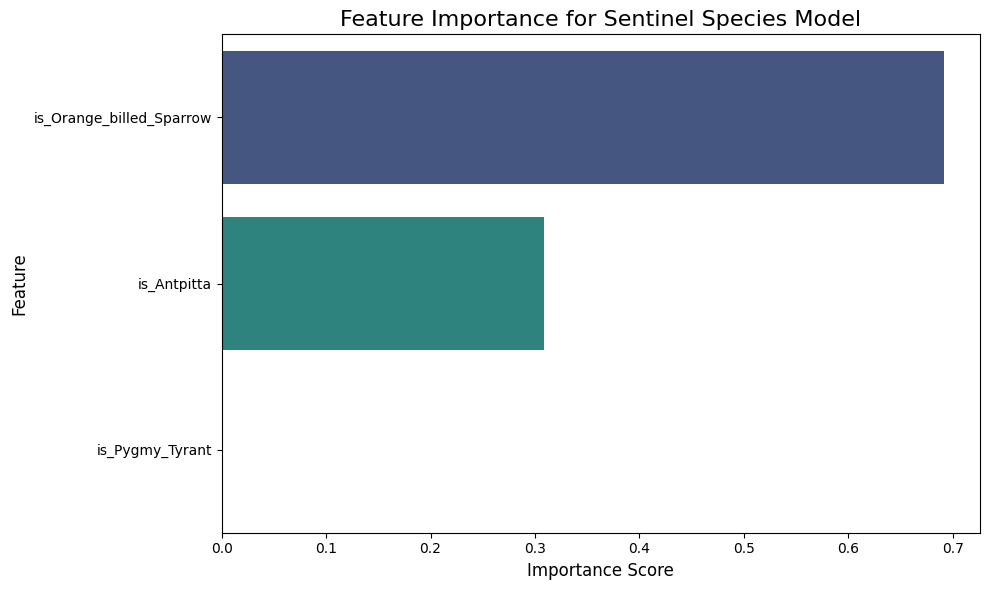

In [43]:
# Train model with only sentinel species
X_sentinel = df[['is_Orange_billed_Sparrow', 'is_Antpitta', 'is_Pygmy_Tyrant']].copy()
y = df['is_simulation'].copy()

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sentinel, y, test_size=0.2, random_state=42, stratify=y
)

xgb_sentinel = xgb.XGBClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    scale_pos_weight=20,
    eval_metric='logloss'
)

xgb_sentinel.fit(X_train_s, y_train_s)
y_pred_proba_sentinel = xgb_sentinel.predict_proba(X_test_s)[:, 1]

print(f"Sentinel species model ROC-AUC: {roc_auc_score(y_test_s, y_pred_proba_sentinel):.4f}")

# Find best threshold
thresholds = np.arange(0.1, 0.9, 0.05)
best_f1_s = 0
best_thresh_s = 0.5

for thresh in thresholds:
    y_pred = (y_pred_proba_sentinel >= thresh).astype(int)
    f1 = f1_score(y_test_s, y_pred)
    if f1 > best_f1_s:
        best_f1_s = f1
        best_thresh_s = thresh

y_pred_sentinel = (y_pred_proba_sentinel >= best_thresh_s).astype(int)

print(f"Best threshold: {best_thresh_s:.2f}, F1: {best_f1_s:.3f}")
print(classification_report(y_test_s, y_pred_sentinel))

print(f"\nFeature importance:")

for i, feature in enumerate(sentinel_features):
    print(f"{feature}: {xgb_sentinel.feature_importances_[i]:.3f}")

plot_feature_importance(
    model=xgb_sentinel, 
    feature_names=X_sentinel.columns, 
    title='Feature Importance for Sentinel Species Model'
)

Combined model ROC-AUC: 0.9460
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    152542
           1       0.16      0.48      0.24      1331

    accuracy                           0.97    153873
   macro avg       0.58      0.73      0.61    153873
weighted avg       0.99      0.97      0.98    153873


Feature importance:
                     feature  importance
0                 RMS Energy    0.203435
10  is_Orange_billed_Sparrow    0.138208
8                    MFCC_12    0.131354
7                     MFCC_9    0.110180
2          Spectral Flatness    0.107376
11               is_Antpitta    0.079221
6                     MFCC_8    0.046717
3         Spectral Bandwidth    0.041211
12           is_Pygmy_Tyrant    0.039991
4     Spectral Rolloff (85%)    0.035542
1          Spectral Contrast    0.034081
9                    MFCC_13    0.018895
5             Onset Strength    0.013788


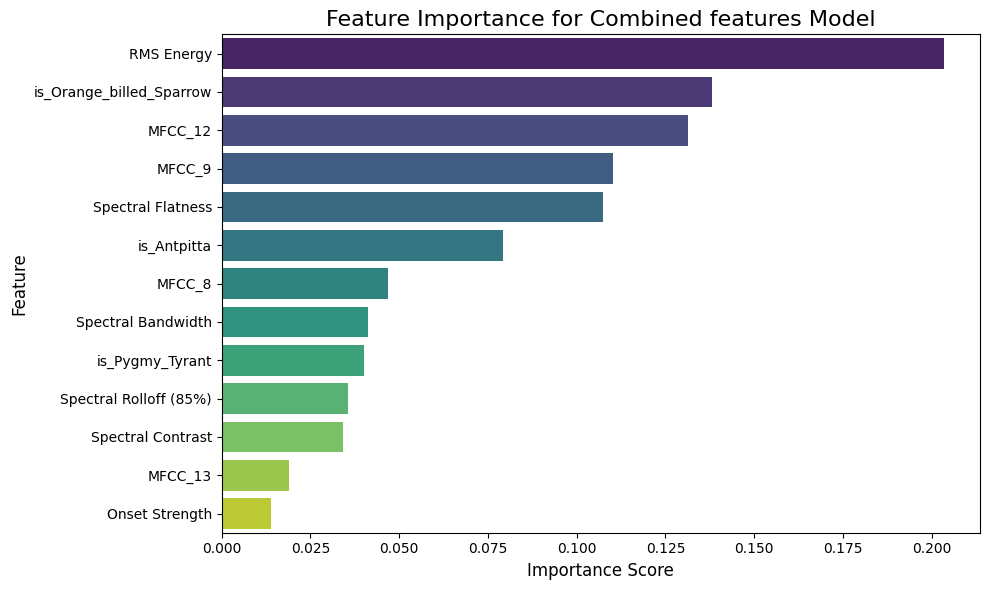

In [47]:


X_combined = df[combined_features].copy()
y = df['is_simulation'].copy()

X_train_cb, X_test_cb, y_train_cb, y_test_cb = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

# Scale only acoustic features
scaler_cb = StandardScaler()
X_train_cb_scaled = X_train_cb.copy()
X_test_cb_scaled = X_test_cb.copy()

X_train_cb_scaled[core_features] = scaler_cb.fit_transform(X_train_cb[core_features])
X_test_cb_scaled[core_features] = scaler_cb.transform(X_test_cb[core_features])

# Use XGBoost
xgb_cb = xgb.XGBClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=20,
    eval_metric='logloss'
)

xgb_cb.fit(X_train_cb_scaled, y_train_cb)
y_pred_cb = xgb_cb.predict(X_test_cb_scaled)
y_pred_proba_cb = xgb_cb.predict_proba(X_test_cb_scaled)[:, 1]

print(f"Combined model ROC-AUC: {roc_auc_score(y_test_cb, y_pred_proba_cb):.4f}")
print(classification_report(y_test_cb, y_pred_cb))

# Check feature importance
importance = pd.DataFrame({
    'feature': combined_features,
    'importance': xgb_cb.feature_importances_
}).sort_values('importance', ascending=False)
print("\nFeature importance:")
print(importance)

plot_feature_importance(
    model=xgb_cb, 
    feature_names=combined_features, 
    title='Feature Importance for Combined features Model'
)

In [32]:
thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for thresh in thresholds:
    y_pred = (y_pred_proba_cb >= thresh).astype(int)
    precision = precision_score(y_test_cb, y_pred)
    recall = recall_score(y_test_cb, y_pred)
    f1 = f1_score(y_test_cb, y_pred)
    results.append([thresh, precision, recall, f1])

results_df = pd.DataFrame(results, columns=['Threshold', 'Precision', 'Recall', 'F1'])

# Find best F1 threshold
best_f1_row = results_df.loc[results_df['F1'].idxmax()]
print(f"Best F1 threshold: {best_f1_row['Threshold']:.2f}")
print(f"Precision: {best_f1_row['Precision']:.3f}, Recall: {best_f1_row['Recall']:.3f}, F1: {best_f1_row['F1']:.3f}")

# Show top 5 thresholds
print("\nTop 5 thresholds by F1:")
print(results_df.nlargest(5, 'F1').round(3))

best_thresh = best_f1_row['Threshold']
y_pred_best = (y_pred_proba_cb >= best_thresh).astype(int)

print(f"\nResults with threshold {best_thresh:.2f}:")
print(classification_report(y_test_cb, y_pred_best))

Best F1 threshold: 0.65
Precision: 0.283, Recall: 0.292, F1: 0.287

Top 5 thresholds by F1:
    Threshold  Precision  Recall     F1
11       0.65      0.283   0.292  0.287
10       0.60      0.242   0.340  0.283
12       0.70      0.334   0.239  0.279
9        0.55      0.198   0.408  0.266
13       0.75      0.408   0.188  0.257

Results with threshold 0.65:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    152542
           1       0.28      0.29      0.29      1331

    accuracy                           0.99    153873
   macro avg       0.64      0.64      0.64    153873
weighted avg       0.99      0.99      0.99    153873



Feature importance (all expanded features):
                     feature  importance
15                 Windspeed    0.217334
13               Temperature    0.154700
16             Datetime_hour    0.107215
10  is_Orange_billed_Sparrow    0.078304
0                 RMS Energy    0.061010
14                  Humidity    0.055978
8                    MFCC_12    0.055621
2          Spectral Flatness    0.044546
3         Spectral Bandwidth    0.042133
12           is_Pygmy_Tyrant    0.036325
6                     MFCC_8    0.033549
7                     MFCC_9    0.029982
9                    MFCC_13    0.029078
4     Spectral Rolloff (85%)    0.020125
1          Spectral Contrast    0.014162
18                confidence    0.010001
11               is_Antpitta    0.006065
5             Onset Strength    0.003870
17      Human Activity Score    0.000000


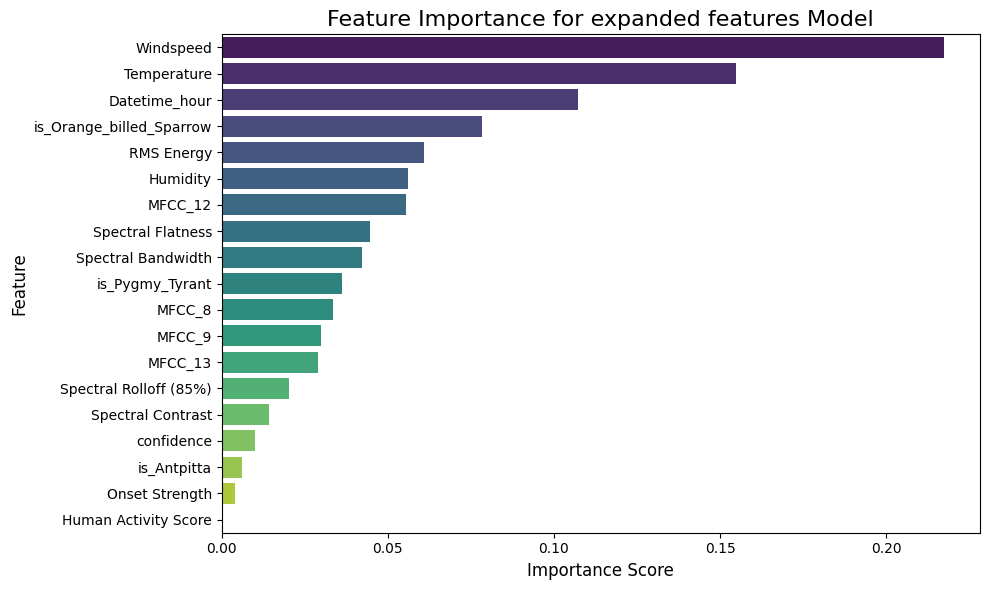

In [48]:
# Use expanded features to find overall importance

X_expanded = df[expanded_features].copy()
y = df['is_simulation'].copy()

X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
    X_expanded, y, test_size=0.2, random_state=42, stratify=y
)

scaler_exp = StandardScaler()
features_to_scale = [f for f in expanded_features if f not in ['is_Orange_billed_Sparrow', 'is_Antpitta', 'is_Pygmy_Tyrant']]

X_train_exp_scaled = X_train_exp.copy()
X_test_exp_scaled = X_test_exp.copy()
X_train_exp_scaled[features_to_scale] = scaler_exp.fit_transform(X_train_exp[features_to_scale])
X_test_exp_scaled[features_to_scale] = scaler_exp.transform(X_test_exp[features_to_scale])

xgb_exp = xgb.XGBClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=20,
    eval_metric='logloss'
)

xgb_exp.fit(X_train_exp_scaled, y_train_exp)

importance_exp = pd.DataFrame({
    'feature': expanded_features,
    'importance': xgb_exp.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature importance (all expanded features):")
print(importance_exp)

plot_feature_importance(
    model=xgb_exp, 
    feature_names=expanded_features, 
    title='Feature Importance for Expanded features Model'
)

In [34]:
# Use sentinel species + top 6 features
custom_features = [
    'is_Orange_billed_Sparrow', 'is_Antpitta', 'is_Pygmy_Tyrant',
    'Windspeed', 'Temperature', 'Datetime_hour', 
    'RMS Energy', 'Humidity', 'MFCC_12'
]

print("Custom features:", custom_features)

X_custom = df[custom_features].copy()
y = df['is_simulation'].copy()

X_train_custom, X_test_custom, y_train_custom, y_test_custom = train_test_split(
    X_custom, y, test_size=0.2, random_state=42, stratify=y
)

scaler_custom = StandardScaler()
features_to_scale_custom = [f for f in custom_features if not f.startswith('is_')]

X_train_custom_scaled = X_train_custom.copy()
X_test_custom_scaled = X_test_custom.copy()
X_train_custom_scaled[features_to_scale_custom] = scaler_custom.fit_transform(X_train_custom[features_to_scale_custom])
X_test_custom_scaled[features_to_scale_custom] = scaler_custom.transform(X_test_custom[features_to_scale_custom])

xgb_custom = xgb.XGBClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=20,
    eval_metric='logloss'
)

xgb_custom.fit(X_train_custom_scaled, y_train_custom)
y_pred_proba_custom = xgb_custom.predict_proba(X_test_custom_scaled)[:, 1]

print(f"\nCustom model ROC-AUC: {roc_auc_score(y_test_custom, y_pred_proba_custom):.4f}")

thresholds = np.arange(0.1, 0.9, 0.05)
best_f1_custom = 0
best_thresh_custom = 0.5

for thresh in thresholds:
    y_pred = (y_pred_proba_custom >= thresh).astype(int)
    f1 = f1_score(y_test_custom, y_pred)
    if f1 > best_f1_custom:
        best_f1_custom = f1
        best_thresh_custom = thresh

y_pred_custom = (y_pred_proba_custom >= best_thresh_custom).astype(int)
print(f"Best threshold: {best_thresh_custom:.2f}, F1: {best_f1_custom:.3f}")
print(classification_report(y_test_custom, y_pred_custom))

Custom features: ['is_Orange_billed_Sparrow', 'is_Antpitta', 'is_Pygmy_Tyrant', 'Windspeed', 'Temperature', 'Datetime_hour', 'RMS Energy', 'Humidity', 'MFCC_12']

Custom model ROC-AUC: 0.9897
Best threshold: 0.80, F1: 0.473
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    152542
           1       0.39      0.59      0.47      1331

    accuracy                           0.99    153873
   macro avg       0.69      0.79      0.73    153873
weighted avg       0.99      0.99      0.99    153873



In [37]:
# Filter data to only include sentinel species detections
sentinel_mask = (df['is_Orange_billed_Sparrow'] == 1) | (df['is_Antpitta'] == 1) | (df['is_Pygmy_Tyrant'] == 1)
df_sentinel_only = df[sentinel_mask].copy()

print(f"Original dataset: {len(df)} rows")
print(f"Sentinel species only: {len(df_sentinel_only)} rows")
print(f"Reduction: {(1 - len(df_sentinel_only)/len(df))*100:.1f}%")

print(f"\nSimulation distribution:")
print(f"Original - Simulations: {df['is_simulation'].sum()}, Total: {len(df)}")
print(f"Filtered - Simulations: {df_sentinel_only['is_simulation'].sum()}, Total: {len(df_sentinel_only)}")

sim_rate_original = df['is_simulation'].mean()
sim_rate_filtered = df_sentinel_only['is_simulation'].mean()
print(f"\nSimulation rate:")
print(f"Original: {sim_rate_original:.4f} ({sim_rate_original*100:.2f}%)")
print(f"Filtered: {sim_rate_filtered:.4f} ({sim_rate_filtered*100:.2f}%)")
print(f"Rate increase: {sim_rate_filtered/sim_rate_original:.2f}x")

Original dataset: 769365 rows
Sentinel species only: 53643 rows
Reduction: 93.0%

Simulation distribution:
Original - Simulations: 6657, Total: 769365
Filtered - Simulations: 1659, Total: 53643

Simulation rate:
Original: 0.0087 (0.87%)
Filtered: 0.0309 (3.09%)
Rate increase: 3.57x


In [38]:


X_filtered = df_sentinel_only[custom_features].copy()
y_filtered = df_sentinel_only['is_simulation'].copy()

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42, stratify=y_filtered
)

print(f"Filtered train set: {len(X_train_f)} rows, Simulations: {y_train_f.sum()}")
print(f"Filtered test set: {len(X_test_f)} rows, Simulations: {y_test_f.sum()}")

scaler_f = StandardScaler()
features_to_scale = [f for f in custom_features if not f.startswith('is_')]

X_train_f_scaled = X_train_f.copy()
X_test_f_scaled = X_test_f.copy()
X_train_f_scaled[features_to_scale] = scaler_f.fit_transform(X_train_f[features_to_scale])
X_test_f_scaled[features_to_scale] = scaler_f.transform(X_test_f[features_to_scale])
pos_weight = (y_train_f == 0).sum() / y_train_f.sum()
print(f"New scale_pos_weight: {pos_weight:.1f}")

xgb_filtered = xgb.XGBClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=pos_weight,
    eval_metric='logloss'
)

xgb_filtered.fit(X_train_f_scaled, y_train_f)
y_pred_proba_f = xgb_filtered.predict_proba(X_test_f_scaled)[:, 1]

print(f"\nFiltered model ROC-AUC: {roc_auc_score(y_test_f, y_pred_proba_f):.4f}")

thresholds = np.arange(0.1, 0.9, 0.05)
best_f1_f = 0
best_thresh_f = 0.5

for thresh in thresholds:
    y_pred = (y_pred_proba_f >= thresh).astype(int)
    f1 = f1_score(y_test_f, y_pred)
    if f1 > best_f1_f:
        best_f1_f = f1
        best_thresh_f = thresh

y_pred_f = (y_pred_proba_f >= best_thresh_f).astype(int)
print(f"Best threshold: {best_thresh_f:.2f}, F1: {best_f1_f:.3f}")
print(classification_report(y_test_f, y_pred_f))

Filtered train set: 42914 rows, Simulations: 1327
Filtered test set: 10729 rows, Simulations: 332
New scale_pos_weight: 31.3

Filtered model ROC-AUC: 0.9908
Best threshold: 0.85, F1: 0.675
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     10397
           1       0.54      0.89      0.68       332

    accuracy                           0.97     10729
   macro avg       0.77      0.93      0.83     10729
weighted avg       0.98      0.97      0.98     10729



## MLP neural network

### 3 sentinel species + 6 high ranking features USING filtered data (only sentinel detection clips) (4 s)

MLP ROC-AUC: 0.9898
Best threshold: 0.40, F1: 0.747
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     10397
           1       0.75      0.75      0.75       332

    accuracy                           0.98     10729
   macro avg       0.87      0.87      0.87     10729
weighted avg       0.98      0.98      0.98     10729

Calculating permutation importance...


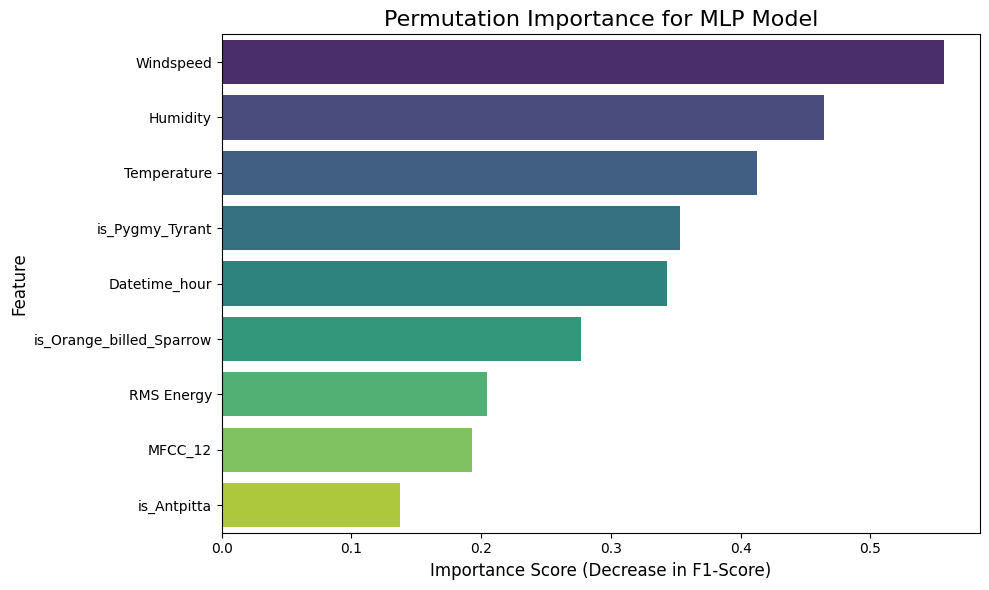

In [53]:
X_train_mlp = X_train_f_scaled.copy()
X_test_mlp = X_test_f_scaled.copy()
y_train_mlp = y_train_f.copy()
y_test_mlp = y_test_f.copy()

mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=0.01,
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)

mlp_model.fit(X_train_mlp, y_train_mlp)
y_pred_proba_mlp = mlp_model.predict_proba(X_test_mlp)[:, 1]

print(f"MLP ROC-AUC: {roc_auc_score(y_test_mlp, y_pred_proba_mlp):.4f}")

thresholds = np.arange(0.1, 0.9, 0.05)
best_f1_mlp = 0
best_thresh_mlp = 0.5

for thresh in thresholds:
    y_pred = (y_pred_proba_mlp >= thresh).astype(int)
    f1 = f1_score(y_test_mlp, y_pred)
    if f1 > best_f1_mlp:
        best_f1_mlp = f1
        best_thresh_mlp = thresh

y_pred_mlp = (y_pred_proba_mlp >= best_thresh_mlp).astype(int)
print(f"Best threshold: {best_thresh_mlp:.2f}, F1: {best_f1_mlp:.3f}")
print(classification_report(y_test_mlp, y_pred_mlp))

plot_permutation_importance(
    model=mlp_model,
    X_test=X_test_mlp,  # Use the scaled test data
    y_test=y_test_mlp,  # Use the test labels
    feature_names=custom_features, # This list must match the columns in X_test_mlp
    title='Permutation Importance for MLP Model'
)

### 3 sentinel species + 6 high ranking features USING full data (38 s)

Full dataset - Train: 615492, Test: 153873
Simulations - Train: 5326, Test: 1331

MLP Full Data ROC-AUC: 0.9877
Best threshold: 0.20, F1: 0.486
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    152542
           1       0.51      0.46      0.49      1331

    accuracy                           0.99    153873
   macro avg       0.75      0.73      0.74    153873
weighted avg       0.99      0.99      0.99    153873

Calculating permutation importance...


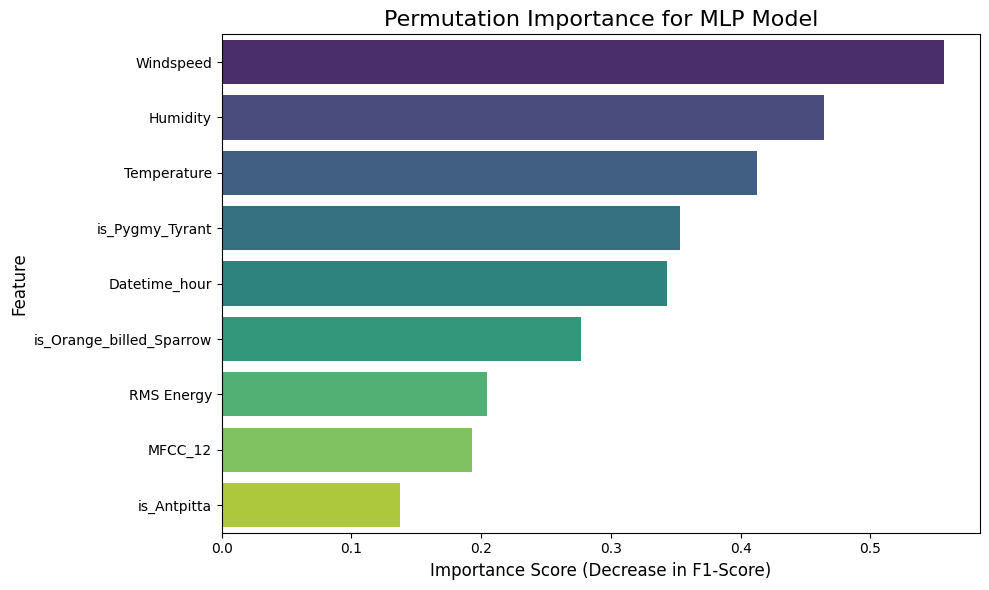

In [52]:
# Use original full dataset
X_full_mlp = df[custom_features].copy()
y_full_mlp = df['is_simulation'].copy()

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full_mlp, y_full_mlp, test_size=0.2, random_state=42, stratify=y_full_mlp
)

scaler_full = StandardScaler()
features_to_scale = [f for f in custom_features if not f.startswith('is_')]

X_train_full_scaled = X_train_full.copy()
X_test_full_scaled = X_test_full.copy()
X_train_full_scaled[features_to_scale] = scaler_full.fit_transform(X_train_full[features_to_scale])
X_test_full_scaled[features_to_scale] = scaler_full.transform(X_test_full[features_to_scale])

print(f"Full dataset - Train: {len(X_train_full)}, Test: {len(X_test_full)}")
print(f"Simulations - Train: {y_train_full.sum()}, Test: {y_test_full.sum()}")

# Train MLP on full data
mlp_full = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=0.01,
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)

mlp_full.fit(X_train_full_scaled, y_train_full)
y_pred_proba_full = mlp_full.predict_proba(X_test_full_scaled)[:, 1]

print(f"\nMLP Full Data ROC-AUC: {roc_auc_score(y_test_full, y_pred_proba_full):.4f}")

# Find best threshold
thresholds = np.arange(0.1, 0.9, 0.05)
best_f1_full = 0
best_thresh_full = 0.5

for thresh in thresholds:
    y_pred = (y_pred_proba_full >= thresh).astype(int)
    f1 = f1_score(y_test_full, y_pred)
    if f1 > best_f1_full:
        best_f1_full = f1
        best_thresh_full = thresh

y_pred_full = (y_pred_proba_full >= best_thresh_full).astype(int)
print(f"Best threshold: {best_thresh_full:.2f}, F1: {best_f1_full:.3f}")
print(classification_report(y_test_full, y_pred_full))

plot_permutation_importance(
    model=mlp_model,
    X_test=X_test_mlp,  # Use the scaled test data
    y_test=y_test_mlp,  # Use the test labels
    feature_names=custom_features, # This list must match the columns in X_test_mlp
    title='Permutation Importance for MLP Model'
)

### 3 sentinel species + 6 high ranking features + acoustic features USING full data (402 s)

In [ ]:
# expanded_features = [
#     'RMS Energy', 'Spectral Contrast', 'Spectral Flatness',
#     'Spectral Bandwidth', 'Spectral Rolloff (85%)', 'Onset Strength', 
#     'MFCC_8', 'MFCC_9', 'MFCC_12', 'MFCC_13',
#     'is_Orange_billed_Sparrow', 'is_Antpitta', 'is_Pygmy_Tyrant',
#     'Temperature', 'Humidity', 'Windspeed', 'Datetime_hour',
#     'Human Activity Score', 'confidence'
# ]

print(f"Total features: {len(expanded_features)}")
print("Features:", expanded_features)

X_exp = df[expanded_features].copy()
y_exp = df['is_simulation'].copy()

X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
    X_exp, y_exp, test_size=0.2, random_state=42, stratify=y_exp
)

# Scale features
scaler_exp = StandardScaler()
features_to_scale_exp = [f for f in expanded_features if not f.startswith('is_')]

X_train_exp_scaled = X_train_exp.copy()
X_test_exp_scaled = X_test_exp.copy()
X_train_exp_scaled[features_to_scale_exp] = scaler_exp.fit_transform(X_train_exp[features_to_scale_exp])
X_test_exp_scaled[features_to_scale_exp] = scaler_exp.transform(X_test_exp[features_to_scale_exp])

mlp_exp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.01,
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)

mlp_exp.fit(X_train_exp_scaled, y_train_exp)
y_pred_proba_exp = mlp_exp.predict_proba(X_test_exp_scaled)[:, 1]

print(f"\nMLP {len(expanded_features)} Features ROC-AUC: {roc_auc_score(y_test_exp, y_pred_proba_exp):.4f}")

thresholds = np.arange(0.1, 0.9, 0.05)
best_f1_exp = 0
best_thresh_exp = 0.5

for thresh in thresholds:
    y_pred = (y_pred_proba_exp >= thresh).astype(int)
    f1 = f1_score(y_test_exp, y_pred)
    if f1 > best_f1_exp:
        best_f1_exp = f1
        best_thresh_exp = thresh

y_pred_exp = (y_pred_proba_exp >= best_thresh_exp).astype(int)
print(f"Best threshold: {best_thresh_exp:.2f}, F1: {best_f1_exp:.3f}")
print(classification_report(y_test_exp, y_pred_exp))

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---> STEP 1: UPDATE YOUR METRICS HERE <---
# Replace the placeholder numbers below with the actual results from your models.
# Make sure to use the scores for the POSITIVE class (label '1').

data = {
    'Model': [
        'Isolation Forest', 
        'LightGBM', 
        'XGBoost (9 features filtered)', 
        'MLP Neural Network (19 features)'
    ],
    'Precision': [0.011, 0.07, 0.54, 0.76],  # <-- Replace with your Precision scores
    'Recall':    [0.363, 0.70, 0.89, 0.77],  # <-- Replace with your Recall scores
    'F1-Score':  [0.021, 0.13, 0.68, 0.77],  # <-- Replace with your F1-Scores
    'ROC-AUC':   [np.nan, 0.9413, 0.9908, 0.9983] # <-- Replace with your ROC-AUC scores (use np.nan for Isolation Forest)
}

# --------------------------------------------------------------------
# ---> STEP 2: RUN THE REST OF THE SCRIPT (No changes needed) <---
# --------------------------------------------------------------------

df_metrics = pd.DataFrame(data)

# Melt the DataFrame to a long format suitable for plotting
df_melted = df_metrics.melt(id_vars='Model', var_name='Metric', value_name='Score')

# Set the visual style and figure size for the chart
sns.set_style("whitegrid")
plt.figure(figsize=(14, 8))

# Create the bar plot using seaborn
ax = sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric', palette='viridis')

# Add the score labels on top of each bar for clarity
for p in ax.patches:
    # Check if the height is a valid number before adding the label
    if not np.isnan(p.get_height()):
        ax.annotate(f'{p.get_height():.2f}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points',
                    fontsize=10)

# Set the titles and labels for the chart
plt.title('Comparison of Machine Learning Model Performance', fontsize=16, weight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xticks(rotation=10, ha='right')
plt.ylim(0, 1.15) # Adjust y-axis to make space for labels above the bars
plt.legend(title='Performance Metric', loc='upper right')
plt.tight_layout()

# Save the plot as an image file and display it
plt.savefig('model_performance_comparison.png')
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---> STEP 1: UPDATE YOUR METRICS HERE <---
# Replace the placeholder numbers below with the actual results from your three MLP models.
# Make sure to use the scores for the POSITIVE class (label '1').

data = {
    'Model': [
        'MLP (Filtered Data)', 
        'MLP (Full Data)', 
        'MLP (Full Data + Acoustic)'
    ],
    'Precision': [0.75, 0.51, 0.76],  # <-- Replace with your Precision scores
    'Recall':    [0.75, 0.46, 0.77],  # <-- Replace with your Recall scores
    'F1-Score':  [0.75, 0.49, 0.77],  # <-- Replace with your F1-Scores
    'ROC-AUC':   [0.9898, 0.9877, 0.9983],  # <-- Replace with your ROC-AUC scores
    'Time (s)':  [4, 38, 402]          # <-- These are your computation times in seconds
}

# --------------------------------------------------------------------
# ---> STEP 2: RUN THE REST OF THE SCRIPT (No changes needed) <---
# --------------------------------------------------------------------

df_mlp = pd.DataFrame(data)

# Set the visual style for the charts
sns.set_style("whitegrid")

# Create a figure with two vertically stacked subplots
fig, axes = plt.subplots(2, 1, figsize=(12, 12))
fig.suptitle('MLP Model Comparison: Performance vs. Computation Time', fontsize=18, weight='bold')

# --- Top Plot: Performance Metrics ---
df_perf = df_mlp.melt(id_vars='Model', value_vars=['Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
                      var_name='Metric', value_name='Score')

ax1 = sns.barplot(data=df_perf, x='Model', y='Score', hue='Metric', ax=axes[0], palette='plasma')
ax1.set_title('Performance Metrics', fontsize=14)
ax1.set_xlabel('') # Remove x-axis label for the top plot
ax1.set_ylabel('Score')
ax1.set_ylim(0, 1.15)
ax1.legend(title='Metric')

# Add score labels on top of each bar for the performance plot
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.2f}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center',
                 xytext=(0, 9),
                 textcoords='offset points',
                 fontsize=9)

# --- Bottom Plot: Computation Time ---
ax2 = sns.barplot(data=df_mlp, x='Model', y='Time (s)', ax=axes[1], palette='cividis')
ax2.set_title('Computation Time', fontsize=14)
ax2.set_xlabel('Model Version', fontsize=12)
ax2.set_ylabel('Time (seconds)')

# Add time labels on top of each bar for the time plot
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.0f} s',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center',
                 xytext=(0, 9),
                 textcoords='offset points',
                 fontsize=10)

# Adjust the layout to prevent titles and labels from overlapping
plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust rect for the main title (suptitle)

# Save the final chart as an image file and display it
plt.savefig('mlp_model_comparison.png')
plt.show()